# 7-qubit Steane QSS — delayed-circuit measurement (DCM) entanglement fidelity

The QSS portion of this notebook is unitary through recovery. Selected shares are **marked for discard** and left untouched after encoding; they are not SWAPped into fresh qubits. A recovery unitary derived from the access structure acts only on the surviving shares and coherently extracts the logical secret. There are no syndrome measurements and no classical feed-forward.

Entanglement fidelity is evaluated with both a direct Bell projector and M3-aware X/Y/Z state tomography. All measurements, including optional measurements of the marked discard wires, occur only at the end of each circuit.

**Execution controls:** `BACKEND_MODE` supports `ideal`, `fake_brisbane`, and `fake_torino`; `USE_M3=True` mitigates the final measured distributions and maps the quasi-distribution to the nearest physical probability distribution.


In [1]:
# The fake backends provide IBM device snapshots; Aer executes noisy simulations from them.
# %pip install "qiskit>=2.0" "qiskit[visualization]" "qiskit-aer>=0.17" "qiskit-ibm-runtime" "mthree>=3.0" matplotlib

In [2]:
from itertools import product, combinations
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.result import marginal_counts
from qiskit.quantum_info import Statevector, state_fidelity

np.set_printoptions(precision=6, suppress=True)
from qiskit.circuit.library import UnitaryGate


In [3]:
# -------------------- USER CONFIG --------------------
ERASED_SHARES = (6, 7)      # or another correctable set from the access-structure helper
SHOTS = 10_000              # 10,000 shots for tomography
OPTIMIZATION_LEVEL = 0      # 0, 1, 2, 3
RUN_TOMOGRAPHY = True

# Execution / mitigation
BACKEND_MODE = "ideal"   # "ideal", "fake_brisbane", or "fake_torino"
USE_M3 = True
M3_CAL_SHOTS = 10_000
M3_CAL_METHOD = "independent"    # fast/suitable for simulator calibration
SEED_TRANSPILE = 12345
SEED_SIMULATOR = 12345

RECOVERY_OUTPUT_SHARE = None
MEASURE_DISCARDED_AT_END = True
# -----------------------------------------------------


In [4]:
# Paper Fig. 5 / Sec. III B.  Secret enters/reappears on physical qubit 1 (index 0).
N = 7
OUTPUT_QUBIT = 0
SYNDROME_QUBITS = (1, 2, 3, 4, 5, 6)

# Reverse of the stabilizer-reduction sequence in Eq. (7), including the Z on q1
# visible at both ends of Figs. 5 and 11.
ENCODER_GATES = [
    ("z", 0),
    ("h", 4), ("h", 5), ("h", 6),
    ("cx", 0, 1), ("cx", 0, 2),
    ("cx", 6, 0), ("cx", 6, 1), ("cx", 6, 3),
    ("cx", 5, 0), ("cx", 5, 2), ("cx", 5, 3),
    ("cx", 4, 1), ("cx", 4, 2), ("cx", 4, 3),
]
DECODER_GATES = list(reversed(ENCODER_GATES))

ALL_SHARES = frozenset(range(1, 8))
STEANE_MINIMAL_AUTHORIZED = tuple(map(frozenset, [
    (1, 2, 3), (1, 4, 5), (1, 6, 7), (2, 4, 6),
    (2, 5, 7), (3, 4, 7), (3, 5, 6),
]))


def steane_is_authorized(shares):
    S = frozenset(shares)
    return any(A <= S for A in STEANE_MINIMAL_AUTHORIZED)


def steane_erasure_is_correctable(erased_shares):
    """For this pure-state QSS code, discarded E must be unauthorized and E^c authorized."""
    E = frozenset(erased_shares)
    if not E <= ALL_SHARES:
        return False
    survivors = ALL_SHARES - E
    return (not steane_is_authorized(E)) and steane_is_authorized(survivors)


def correctable_steane_erasures(size):
    return [c for c in combinations(sorted(ALL_SHARES), size)
            if steane_erasure_is_correctable(c)]


def validate_steane_erasure(erased_shares):
    E = tuple(sorted(set(erased_shares)))
    if len(E) != len(tuple(erased_shares)):
        raise ValueError("Do not repeat a share index.")
    if not set(E) <= ALL_SHARES:
        raise ValueError(f"Shares must be chosen from {sorted(ALL_SHARES)}")
    if not steane_erasure_is_correctable(E):
        survivors = tuple(sorted(ALL_SHARES - set(E)))
        raise ValueError(
            f"E={E} is not a correctable erasure set for the Steane QSS access structure. "
            f"Survivors are {survivors}. Use correctable_steane_erasures(len(E)) "
            "to list valid choices of the same size."
        )
    return E


def prepare_qubit_secret(qc, qubit, theta, phi):
    qc.rx(theta, qubit)
    qc.rz(phi, qubit)


In [5]:
def append_gate_list(qc, qreg, gates):
    """Apply the paper encoder gate list to an indexable qubit collection."""
    for gate in gates:
        kind = gate[0]
        if kind == "h":
            qc.h(qreg[gate[1]])
        elif kind == "x":
            qc.x(qreg[gate[1]])
        elif kind == "z":
            qc.z(qreg[gate[1]])
        elif kind == "cx":
            qc.cx(qreg[gate[1]], qreg[gate[2]])
        elif kind == "cz":
            qc.cz(qreg[gate[1]], qreg[gate[2]])
        else:
            raise ValueError(gate)


def _encoded_logical_basis_states():
    """Return |0_L> and |1_L> generated by the paper encoder."""
    states = []
    for logical in (0, 1):
        qc = QuantumCircuit(N)
        if logical:
            qc.x(OUTPUT_QUBIT)
        append_gate_list(qc, qc.qubits, ENCODER_GATES)
        states.append(np.asarray(Statevector.from_instruction(qc).data, dtype=complex))
    return states


_LOGICAL_0, _LOGICAL_1 = _encoded_logical_basis_states()


def _bipartite_amplitude_matrix(state, erased0, survivors0):
    """Matrix M[e,a] for the split erased-environment E | surviving set A.

    Qiskit basis indices are little-endian.  ``erased0`` and ``survivors0`` are
    physical zero-based code-qubit indices; their tuple order defines the local
    basis order inside M.
    """
    M = np.zeros((2 ** len(erased0), 2 ** len(survivors0)), dtype=complex)
    for basis_index, amp in enumerate(state):
        e_index = sum(((basis_index >> q) & 1) << j for j, q in enumerate(erased0))
        a_index = sum(((basis_index >> q) & 1) << j for j, q in enumerate(survivors0))
        M[e_index, a_index] = amp
    return M


def _complete_orthonormal_basis(prefix, tol=1e-10):
    """Deterministically extend orthonormal columns to a full unitary basis."""
    cols = [prefix[:, i].copy() for i in range(prefix.shape[1])]
    dim = prefix.shape[0]
    for j in range(dim):
        v = np.zeros(dim, dtype=complex)
        v[j] = 1.0
        for q in cols:
            v -= q * np.vdot(q, v)
        norm = np.linalg.norm(v)
        if norm > tol:
            cols.append(v / norm)
        if len(cols) == dim:
            break
    Q = np.column_stack(cols)
    if not np.allclose(Q.conj().T @ Q, np.eye(dim), atol=1e-8):
        raise RuntimeError("Failed to complete the DCM recovery basis.")
    return Q


def _choose_recovery_output(erased_shares, requested_share=None):
    erased = set(erased_shares)
    survivors = sorted(ALL_SHARES - erased)
    if not survivors:
        raise ValueError("At least one surviving share is required.")

    if requested_share is not None:
        requested_share = int(requested_share)
        if requested_share not in survivors:
            raise ValueError(
                f"RECOVERY_OUTPUT_SHARE={requested_share} is discarded. "
                f"Choose one of the surviving shares {survivors}, or use None."
            )
        return requested_share

    paper_output_share = OUTPUT_QUBIT + 1
    return paper_output_share if paper_output_share in survivors else survivors[0]


_DCM_RECOVERY_CACHE = {}


def derive_dcm_recovery_unitary(erased_shares, recovery_output_share=None, tol=1e-9):
    """Construct the fully coherent authorized-set recovery used by the DCM notebooks.

    The discarded shares are *not* SWAPped into fresh qubits.  They remain in the
    circuit as the environment and are never acted on after the encoding stage.

    For a correctable erasure E, Knill-Laflamme/QSS decoupling implies that the
    two logical codewords have the same reduced state on E and zero logical
    cross-term there.  A Schmidt-basis construction then gives a unitary on the
    surviving shares alone that extracts the logical qubit.

    Returns
    -------
    U : ndarray
        Recovery unitary acting only on the surviving physical shares.
    survivors0 : tuple[int]
        Zero-based physical code-qubit indices, in the qarg order expected by U.
    output0 : int
        Zero-based physical share on which the logical secret is recovered.
    info : dict
        Diagnostics about the erased reduced state and Schmidt rank.
    """
    erased_shares = tuple(sorted(erased_shares))
    key = (erased_shares, recovery_output_share)
    if key in _DCM_RECOVERY_CACHE:
        return _DCM_RECOVERY_CACHE[key]

    erased0 = tuple(s - 1 for s in erased_shares)
    survivors0 = tuple(q for q in range(N) if q not in erased0)
    output_share = _choose_recovery_output(erased_shares, recovery_output_share)
    output0 = output_share - 1

    M0 = _bipartite_amplitude_matrix(_LOGICAL_0, erased0, survivors0)
    M1 = _bipartite_amplitude_matrix(_LOGICAL_1, erased0, survivors0)

    rho_e0 = M0 @ M0.conj().T
    rho_e1 = M1 @ M1.conj().T
    cross_e = M0 @ M1.conj().T

    rho_mismatch = float(np.linalg.norm(rho_e0 - rho_e1))
    cross_norm = float(np.linalg.norm(cross_e))
    if rho_mismatch > 1e-7 or cross_norm > 1e-7:
        raise ValueError(
            "Selected discarded set is not decoupled from the logical secret: "
            f"||rho_E(0)-rho_E(1)||={rho_mismatch:.3e}, "
            f"||Tr_A |0_L><1_L|||={cross_norm:.3e}."
        )

    rho_e = (rho_e0 + rho_e1) / 2
    eigvals, eigvecs = np.linalg.eigh(rho_e)
    active = [i for i, value in enumerate(eigvals) if value > tol]
    active.sort(key=lambda i: eigvals[i], reverse=True)

    dim_a = 2 ** len(survivors0)
    schmidt_rank = len(active)
    if 2 * schmidt_rank > dim_a:
        raise ValueError(
            "The surviving Hilbert space is too small to coherently extract the "
            "logical qubit for this discard set."
        )

    output_local = survivors0.index(output0)
    junk_positions = [i for i in range(len(survivors0)) if i != output_local]

    source_cols = []
    target_cols = []

    for r, eig_index in enumerate(active):
        lam = float(np.real(eigvals[eig_index]))
        env_vec = eigvecs[:, eig_index]

        # <env_r|psi_b> / sqrt(lambda_r): normalized Schmidt partner on A.
        a0 = M0.T @ env_vec.conj() / np.sqrt(lam)
        a1 = M1.T @ env_vec.conj() / np.sqrt(lam)

        for logical, source in ((0, a0), (1, a1)):
            source_cols.append(source)

            target_index = logical << output_local
            for j, pos in enumerate(junk_positions):
                target_index |= ((r >> j) & 1) << pos
            target = np.zeros(dim_a, dtype=complex)
            target[target_index] = 1.0
            target_cols.append(target)

    S = np.column_stack(source_cols)
    T = np.column_stack(target_cols)
    if not np.allclose(S.conj().T @ S, np.eye(S.shape[1]), atol=1e-8):
        raise RuntimeError("Derived logical Schmidt vectors are not orthonormal.")

    source_basis = _complete_orthonormal_basis(S)
    target_basis = _complete_orthonormal_basis(T)
    U = target_basis @ source_basis.conj().T

    if not np.allclose(U.conj().T @ U, np.eye(dim_a), atol=1e-8):
        raise RuntimeError("Derived DCM recovery is not unitary.")

    info = {
        "discarded_shares": erased_shares,
        "surviving_shares": tuple(q + 1 for q in survivors0),
        "recovery_output_share": output_share,
        "schmidt_rank": schmidt_rank,
        "rho_mismatch": rho_mismatch,
        "logical_cross_norm": cross_norm,
    }
    result = (U, survivors0, output0, info)
    _DCM_RECOVERY_CACHE[key] = result
    return result


def append_dcm_recovery(qc, code_q, erased_shares, recovery_output_share=None):
    """Append the coherent DCM recovery to the surviving shares only."""
    U, survivors0, output0, info = derive_dcm_recovery_unitary(
        erased_shares, recovery_output_share
    )
    gate = UnitaryGate(U, label=f"DCM_R_E{''.join(map(str, erased_shares))}")
    qc.append(gate, [code_q[q] for q in survivors0])
    discarded = tuple(code_q[s - 1] for s in erased_shares)
    return code_q[output0], discarded, info

def make_execution_backend(mode=BACKEND_MODE):
    """Return an Aer execution backend.

    Modes
    -----
    ideal          : noiseless AerSimulator
    fake_brisbane  : Aer noise model / coupling / basis derived from FakeBrisbane
    fake_torino    : Aer noise model / coupling / basis derived from FakeTorino

    For the fake modes, AerSimulator.from_backend(...) copies the fake device
    snapshot into a local noisy simulator.  Circuits are transpiled against this
    simulator, so the final physical-qubit mapping can be passed directly to M3.
    """
    mode = mode.lower()
    if mode == "ideal":
        return AerSimulator(), "ideal AerSimulator"

    try:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeTorino
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Fake backends require qiskit-ibm-runtime. Uncomment the %pip install cell."
        ) from exc

    if mode == "fake_brisbane":
        snapshot = FakeBrisbane()
    elif mode == "fake_torino":
        snapshot = FakeTorino()
    else:
        raise ValueError(
            "BACKEND_MODE must be 'ideal', 'fake_brisbane', or 'fake_torino'."
        )
    return AerSimulator.from_backend(snapshot), snapshot.name


EXECUTION_BACKEND, BACKEND_LABEL = make_execution_backend()
print("Execution backend:", BACKEND_LABEL)
print("M3 enabled:", USE_M3)


def run_counts(circuit, shots=20000, optimization_level=0, backend=None):
    backend = EXECUTION_BACKEND if backend is None else backend
    compiled = transpile(
        circuit,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    return compiled, result.get_counts()


def _m3_module():
    try:
        import mthree
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "USE_M3=True requires mthree. Uncomment the %pip install cell."
        ) from exc
    return mthree


def selected_raw_marginal(counts, circuit, clbits):
    indices = [circuit.find_bit(c).index for c in clbits]
    return marginal_counts(counts, indices=indices)


def m3_mitigated_marginal(compiled, counts, original_circuit, clbits, backend=None):
    """M3-correct only the requested *final metric* bits.

    This intentionally does not attempt to change the single-shot syndrome values
    that drove mid-circuit feed-forward. M3 can correct ensemble measurement
    statistics, but not a classical decision that already happened during a shot.
    """
    mthree = _m3_module()
    backend = EXECUTION_BACKEND if backend is None else backend
    indices = [original_circuit.find_bit(c).index for c in clbits]
    full_mapping = mthree.utils.final_measurement_mapping(compiled)
    marginal_raw, marginal_mapping = mthree.utils.marginal_distribution(
        counts, indices, full_mapping
    )
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(
        marginal_mapping,
        shots=M3_CAL_SHOTS,
        method=M3_CAL_METHOD,
        async_cal=False,
    )
    quasi = mit.apply_correction(marginal_raw, marginal_mapping)
    # Maps M3 quasi-probabilities to the closest probability
    # distribution in L2 norm before reporting probabilities/fidelities.
    probs = quasi.nearest_probability_distribution()
    return marginal_raw, quasi, probs, marginal_mapping


def probability_zero_from_distribution(dist):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0", 0.0) / total)


def probability_all_zero_from_distribution(dist, nbits):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0" * nbits, 0.0) / total)




def build_direct_bell_projector(base_circuit, ref_qubit, recovered_qubit,
                                discarded_qubits=()):
    """Append the inverse Bell preparation; all measurements remain final."""
    qc = base_circuit.copy()

    ref_idx = base_circuit.find_bit(ref_qubit).index
    out_idx = base_circuit.find_bit(recovered_qubit).index
    discard_indices = [base_circuit.find_bit(q).index for q in discarded_qubits]

    ref_q = qc.qubits[ref_idx]
    out_q = qc.qubits[out_idx]

    qc.cx(ref_q, out_q)
    qc.h(ref_q)

    fid = ClassicalRegister(2, "fid")
    qc.add_register(fid)
    qc.measure(ref_q, fid[0])
    qc.measure(out_q, fid[1])

    if MEASURE_DISCARDED_AT_END and discard_indices:
        discard = ClassicalRegister(len(discard_indices), "discard")
        qc.add_register(discard)
        for i, qidx in enumerate(discard_indices):
            qc.measure(qc.qubits[qidx], discard[i])

    return qc, fid

# -------- M3-aware Pauli state tomography --------
# This explicitly runs the 3^n X/Y/Z measurement settings so the same M3
# correction can be applied to every tomography histogram before reconstruction.

_TOMO_PAULI_MATS = {
    "I": np.array([[1, 0], [0, 1]], dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}


def _probabilities_from_counts(counts):
    total = float(sum(counts.values()))
    return {key.replace(" ", ""): value / total for key, value in counts.items()}


def _expectation_from_distribution(dist, pauli_tuple):
    n = len(pauli_tuple)
    value = 0.0
    for key, prob in dist.items():
        bitstring = "".join(ch for ch in str(key) if ch in "01")
        if len(bitstring) != n:
            raise ValueError(f"Expected {n}-bit marginal, got key {key!r}")
        # Qiskit displays classical bit n-1 on the left and bit 0 on the right.
        bits = [int(ch) for ch in bitstring[::-1]]
        parity = sum(bits[i] for i, p in enumerate(pauli_tuple) if p != "I") % 2
        value += (-1.0 if parity else 1.0) * float(prob)
    return value


def _pauli_operator(pauli_tuple):
    # Qiskit little-endian convention: highest-index local qubit is leftmost
    # in the Kronecker product representation.
    out = np.array([[1.0 + 0j]])
    for p in reversed(pauli_tuple):
        out = np.kron(out, _TOMO_PAULI_MATS[p])
    return out


def _linear_inversion_density(probabilities_by_setting, n):
    dim = 2 ** n
    rho = np.zeros((dim, dim), dtype=complex)
    for pauli_tuple in product("IXYZ", repeat=n):
        if all(p == "I" for p in pauli_tuple):
            expval = 1.0
        else:
            setting = tuple(p if p != "I" else "Z" for p in pauli_tuple)
            expval = _expectation_from_distribution(
                probabilities_by_setting[setting], pauli_tuple
            )
        rho += expval * _pauli_operator(pauli_tuple)
    rho /= dim
    return (rho + rho.conj().T) / 2


def _pure_state_fidelity_from_rho(rho, target_statevector):
    psi = np.asarray(target_statevector.data, dtype=complex)
    value = float(np.real(np.vdot(psi, rho @ psi)))
    return float(np.clip(value, 0.0, 1.0))


def run_m3_state_tomography(base_circuit, target_qubits, target_statevector,
                            shots=10000, optimization_level=0, backend=None,
                            discarded_qubits=()):
    """Return raw and (optionally) M3-mitigated linear-inversion fidelities.

    target_qubits is an ordered sequence of qubit objects in base_circuit. The
    reconstructed density matrix uses exactly that local ordering.
    """
    backend = EXECUTION_BACKEND if backend is None else backend
    target_indices = [base_circuit.find_bit(q).index for q in target_qubits]
    n = len(target_indices)
    settings = list(product("XYZ", repeat=n))
    circuits = []

    for axes in settings:
        qc = base_circuit.copy()
        tomo = ClassicalRegister(n, "tomo")
        qc.add_register(tomo)
        for i, (qidx, axis) in enumerate(zip(target_indices, axes)):
            q = qc.qubits[qidx]
            if axis == "X":
                qc.h(q)
            elif axis == "Y":
                qc.sdg(q)
                qc.h(q)
            qc.measure(q, tomo[i])

        if MEASURE_DISCARDED_AT_END and discarded_qubits:
            discard = ClassicalRegister(len(discarded_qubits), "discard")
            qc.add_register(discard)
            for i, dq in enumerate(discarded_qubits):
                dq_idx = base_circuit.find_bit(dq).index
                qc.measure(qc.qubits[dq_idx], discard[i])
        circuits.append(qc)

    compiled = transpile(
        circuits,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    raw_counts = result.get_counts()
    if isinstance(raw_counts, dict):
        raw_counts = [raw_counts]

    # The tomography register is appended after any syndrome registers.
    tomo_indices = list(range(base_circuit.num_clbits, base_circuit.num_clbits + n))

    if USE_M3:
        mthree = _m3_module()
        mappings = mthree.utils.final_measurement_mapping(compiled)
        marg_counts = []
        marg_mappings = []
        for counts, mapping in zip(raw_counts, mappings):
            mc, mm = mthree.utils.marginal_distribution(counts, tomo_indices, mapping)
            marg_counts.append(mc)
            marg_mappings.append(mm)

        mit = mthree.M3Mitigation(backend)
        mit.cals_from_system(
            marg_mappings,
            shots=M3_CAL_SHOTS,
            method=M3_CAL_METHOD,
            async_cal=False,
        )
        quasis = mit.apply_correction(marg_counts, marg_mappings)
        mitigated_probs = [q.nearest_probability_distribution() for q in quasis]
    else:
        marg_counts = [marginal_counts(c, indices=tomo_indices) for c in raw_counts]
        mitigated_probs = None

    raw_probs = [_probabilities_from_counts(c) for c in marg_counts]
    raw_by_setting = dict(zip(settings, raw_probs))
    rho_raw = _linear_inversion_density(raw_by_setting, n)
    fid_raw = _pure_state_fidelity_from_rho(rho_raw, target_statevector)

    out = {
        "raw_fidelity": fid_raw,
        "raw_density_matrix": rho_raw,
        "compiled_circuits": compiled,
    }
    if mitigated_probs is not None:
        mit_by_setting = dict(zip(settings, mitigated_probs))
        rho_m3 = _linear_inversion_density(mit_by_setting, n)
        out["m3_fidelity"] = _pure_state_fidelity_from_rho(rho_m3, target_statevector)
        out["m3_density_matrix"] = rho_m3
    return out


Execution backend: ideal AerSimulator
M3 enabled: True


In [6]:

ERASED_SHARES = validate_steane_erasure(ERASED_SHARES)
U_DCM, survivors0, output0, recovery_info = derive_dcm_recovery_unitary(
    ERASED_SHARES, RECOVERY_OUTPUT_SHARE
)
print("Selected discard set:", ERASED_SHARES)
print("DCM recovery:", recovery_info)


Selected discard set: (6, 7)
DCM recovery: {'discarded_shares': (6, 7), 'surviving_shares': (1, 2, 3, 4, 5), 'recovery_output_share': 1, 'schmidt_rank': 4, 'rho_mismatch': 0.0, 'logical_cross_norm': 0.0}


Recovery info: {'discarded_shares': (6, 7), 'surviving_shares': (1, 2, 3, 4, 5), 'recovery_output_share': 1, 'schmidt_rank': 4, 'rho_mismatch': 0.0, 'logical_cross_norm': 0.0}


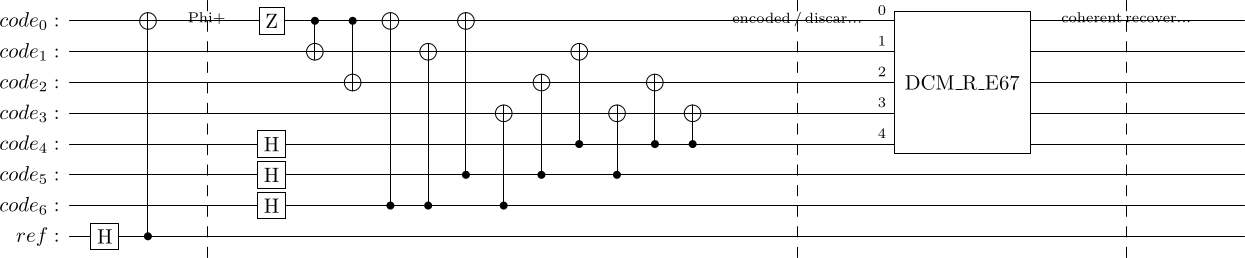

In [7]:

def build_entanglement_channel_circuit(erased_shares=ERASED_SHARES,
                                       recovery_output_share=RECOVERY_OUTPUT_SHARE):
    erased_shares = validate_steane_erasure(erased_shares)

    code_q = QuantumRegister(N, "code")
    ref = QuantumRegister(1, "ref")
    qc = QuantumCircuit(code_q, ref)

    # |Phi+> between untouched reference and the secret input.
    qc.h(ref[0])
    qc.cx(ref[0], code_q[OUTPUT_QUBIT])
    qc.barrier(label="Phi+")

    append_gate_list(qc, code_q, ENCODER_GATES)
    qc.barrier(label="encoded / discard set fixed")

    # Fully coherent DCM recovery: no SWAP erasure, no measurement, no feed-forward.
    recovered_q, discarded_q, info = append_dcm_recovery(
        qc, code_q, erased_shares, recovery_output_share
    )
    qc.barrier(label="coherent recovery")
    return qc, ref[0], recovered_q, discarded_q, info


channel_qc, ref_q, recovered_q, discarded_q, recovery_info = build_entanglement_channel_circuit()
print("Recovery info:", recovery_info)
display(channel_qc.draw(output="latex", cregbundle=False))


In [8]:

projector_qc, fid = build_direct_bell_projector(
    channel_qc, ref_q, recovered_q, discarded_q
)
compiled, counts = run_counts(
    projector_qc, shots=SHOTS, optimization_level=OPTIMIZATION_LEVEL
)
raw_fid_counts = selected_raw_marginal(counts, projector_qc, list(fid))
Fe_raw = probability_all_zero_from_distribution(raw_fid_counts, 2)
print("Backend:", BACKEND_LABEL)
print("Direct raw DCM entanglement fidelity estimate:", Fe_raw)
print("Raw projector counts:", raw_fid_counts)

if USE_M3:
    _, quasi, m3_probs, mapping = m3_mitigated_marginal(
        compiled, counts, projector_qc, list(fid)
    )
    Fe_m3 = probability_all_zero_from_distribution(m3_probs, 2)
    print("M3 physical-qubit mapping:", mapping)
    print("Direct M3 DCM entanglement fidelity estimate:", Fe_m3)
    print("M3 nearest probability distribution:", m3_probs)


Backend: ideal AerSimulator
Direct raw DCM entanglement fidelity estimate: 1.0
Raw projector counts: {'00': 10000}
M3 physical-qubit mapping: {0: 7, 1: 0}
Direct M3 DCM entanglement fidelity estimate: 1.0
M3 nearest probability distribution: {'00': np.float32(1.0)}


In [9]:

if RUN_TOMOGRAPHY:
    bell = Statevector([1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)])
    tomo = run_m3_state_tomography(
        channel_qc,
        [ref_q, recovered_q],
        bell,
        shots=SHOTS,
        optimization_level=OPTIMIZATION_LEVEL,
        discarded_qubits=discarded_q,
    )
    print("Tomographic raw DCM entanglement fidelity:", tomo["raw_fidelity"])
    if USE_M3:
        print("Tomographic M3 DCM entanglement fidelity:", tomo["m3_fidelity"])


Tomographic raw DCM entanglement fidelity: 0.9999999999999998
Tomographic M3 DCM entanglement fidelity: 1.0
